# Importação de Pacotes

In [9]:
#leitura da base de dados
import pandas as pd
from pathlib import Path

#modelo preditivo escolhido
from sklearn.ensemble import GradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

In [10]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(
        ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
    )

    print(f"""
      Acurária: {round(acuracia,3)};
      Revocação: {round(recall,3)};
      F1: {round(F1,3)};
      Roc_Auc: {round(roc_auc,3)}""")

## Leitura DataFrame

In [11]:
direcao = Path("../..") / "data"
caminho = direcao / "dados_confrontados_completo.csv"

df = pd.read_csv(caminho)

### Escolha do Modelo

In [12]:
modelo= GradientBoostingClassifier()

### Escolha dos HiperParâmetros

In [13]:
parametros = {
    "modelo__n_estimators": [100], 
    "modelo__max_depth": [2], 
    "modelo__max_leaf_nodes": [10],
    "modelo__learning_rate": [0.2]
    }

In [14]:
df.shape

(1310, 96)

In [15]:
df.columns

Index(['d', 'data_peticao', 'tipo_documento', 'materialidade_valor',
       'materialidade_categoria', 'legitimidade_representante',
       'tipo_legitimidade', 'clareza_objetividade', 'fundamentacao_minima',
       'indicios_irregularidade', 'competencia_tcu', 'recursos_federais',
       'demanda_privada', 'interesse_publico',
       'type_restricao_admissibilidade', 'type_evidencia_indicio_minimo',
       'type_aceitabilidade_evidencia_jornalistica', 'type_nivel_indicio',
       'pedido_medida_cautelar', 'contrato_vigente', 'contrato_iminente',
       'criticidade_objeto', 'certame_suspenso', 'risco_erario',
       'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe',
       'type_contrato_objeto_previsto', 'type_regularizacao_requisito',
       'type_defesa_ente_administrativo', 'type_impacto_irregularidade',
       'perigo_demora_reverso', 'fumus_boni_iuris', 'categoria_irregularidade',
       'dano_potencial_alto', 'dano_potencial_medio',
       'nexo_causal_identif

# Aplicação de Pipelines

In [16]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.2], 'modelo__max_depth': [2], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.728;
      Revocação: 0.404;
      F1: 0.462;
      Roc_Auc: 0.632


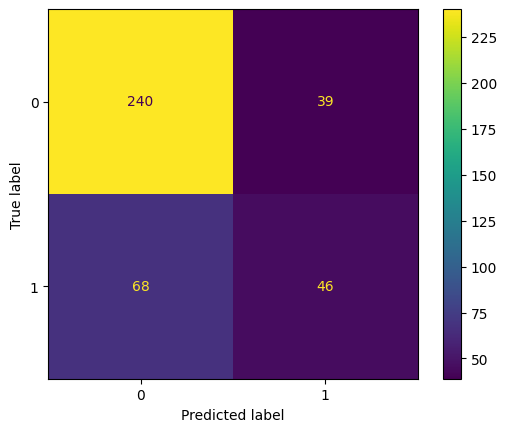

In [17]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Teste com mais Parâmetros**

In [18]:
parametros = {
    "modelo__n_estimators": [100, 200, 1000], 
    "modelo__max_depth": [1, 2, 3], 
    "modelo__max_leaf_nodes": [10, 20, 30],
    "modelo__learning_rate": [0.01, 0.2, 1.0]
    }

In [31]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=10
)

searchCV_pipeline.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.01, 0.2, ...], 'modelo__max_depth': [1, 2, ...], 'modelo__max_leaf_nodes': [10, 20, ...], 'modelo__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.735;
      Revocação: 0.404;
      F1: 0.469;
      Roc_Auc: 0.637


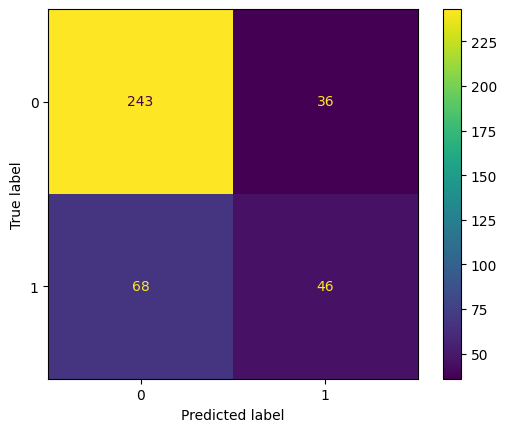

In [32]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Extração de Amostras para Análise Qualitativa de Falsos Positivos e Negativos**

In [21]:
import numpy as np

y_pred = searchCV_pipeline.predict(X_test)

resultados = X_test.copy()
resultados["y"] = y_test.values
resultados["y_pred"] = y_pred

resultados["d"] = df.loc[resultados.index, "d"].values

falso_positivo = resultados[(resultados["y"] == 0) & (resultados["y_pred"] == 1)]
falso_negativo = resultados[(resultados["y"] == 1) & (resultados["y_pred"] == 0)]

amostra_fp = falso_positivo.sample(n=min(10, len(falso_positivo)), random_state=22)
amostra_fn= falso_negativo.sample(n=min(10, len(falso_negativo)), random_state=22)

### Análise Falso Positivo

In [22]:
len(falso_positivo)

26

In [23]:
amostra_fp

,materialidade_valor,materialidade_categoria,legitimidade_representante,tipo_legitimidade,clareza_objetividade,fundamentacao_minima,indicios_irregularidade,competencia_tcu,recursos_federais,demanda_privada,...,evidencias_midiaticas,evidencias_testemunhais,qualidade_evidencias_forte,qualidade_evidencias_moderada,autenticidade_documentos_certificada,autenticidade_documentos_presumida,resposta_ente_convincente,y,y_pred,d
209,4.749900e+05,media,sim,cidadao,sim,sim,sim,sim,sim,nao,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,1,74490545
59,1.300000e+06,media,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,73387147
533,0.000000e+00,baixa,sim,mpu,sim,sim,sim,sim,nao,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,75810992
934,1.400000e+09,alta,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,77425910
138,3.852000e+05,media,sim,orgao_controle,sim,sim,sim,sim,sim,nao,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0,1,74155830
120,2.572699e+05,media,sim,cidadao,sim,sim,sim,nao,sim,nao,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,74114657
174,3.000000e+05,media,sim,mpu,sim,sim,sim,sim,nao,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,74273789
307,1.400000e+09,alta,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,74835682
338,3.581500e+06,media,sim,outro,sim,sim,sim,sim,sim,nao,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,1,74972613
970,0.000000e+00,baixa,sim,parlamentar,sim,sim,sim,sim,nao,nao,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1,77495754


### Análise Falso Negativo

In [24]:
len(falso_negativo)

78

In [25]:
amostra_fn

,materialidade_valor,materialidade_categoria,legitimidade_representante,tipo_legitimidade,clareza_objetividade,fundamentacao_minima,indicios_irregularidade,competencia_tcu,recursos_federais,demanda_privada,...,evidencias_midiaticas,evidencias_testemunhais,qualidade_evidencias_forte,qualidade_evidencias_moderada,autenticidade_documentos_certificada,autenticidade_documentos_presumida,resposta_ente_convincente,y,y_pred,d
920,6.721000e+08,alta,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,77377063
113,0.000000e+00,baixa,sim,outro,sim,sim,sim,sim,sim,nao,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0,74090629
386,2.025756e+07,alta,sim,orgao_controle,sim,sim,sim,sim,sim,nao,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1,0,75126458
469,1.000000e+08,alta,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1,0,75435798
859,9.025039e+05,media,sim,outro,sim,sim,sim,sim,sim,nao,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0,77114042
861,1.021172e+06,media,sim,outro,sim,sim,sim,sim,sim,nao,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,0,77122537
3,2.300000e+03,baixa,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,72765523
936,4.080000e+09,alta,sim,parlamentar,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0,77429044
22,6.973520e+05,media,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0,72932468
263,2.200000e+10,alta,sim,mpu,sim,sim,sim,sim,sim,nao,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1,0,74682533


# Feature Importance aplicada à Base de Dados (Shapley)

In [26]:
import shap

best_pipeline = searchCV_pipeline.best_estimator_

best_model = best_pipeline.named_steps["modelo"]
preprocessor = best_pipeline.named_steps["preprocessor"]

X_importance = preprocessor.transform(X_test)

cat_encoder = (preprocessor.named_transformers_["cat"].named_steps["onehot"])

feature_names = list(cat_encoder.get_feature_names_out(lista_X))


c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


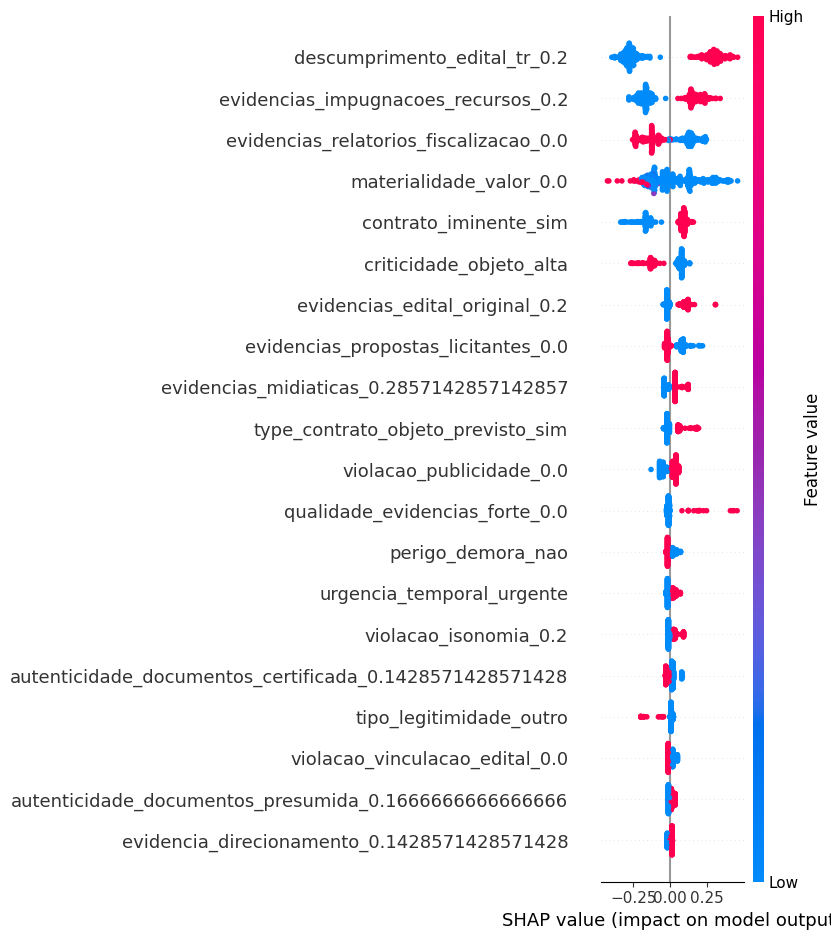

In [27]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_importance)

shap.summary_plot(shap_values, X_importance, feature_names)

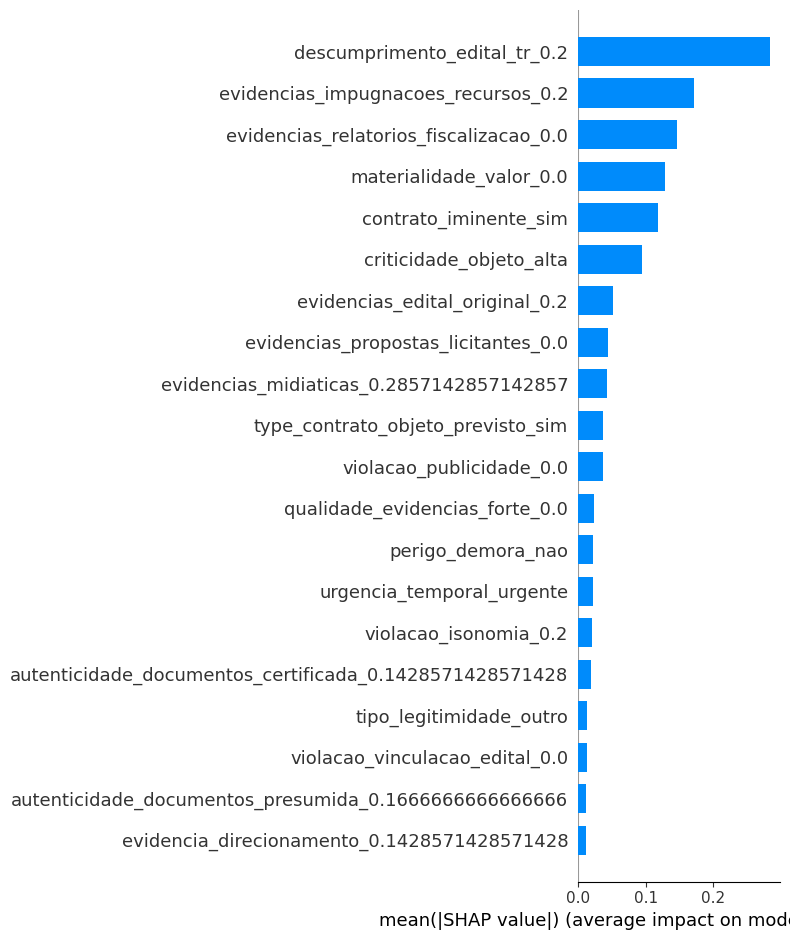

In [28]:
shap.summary_plot(shap_values, X_importance, feature_names, plot_type='bar')

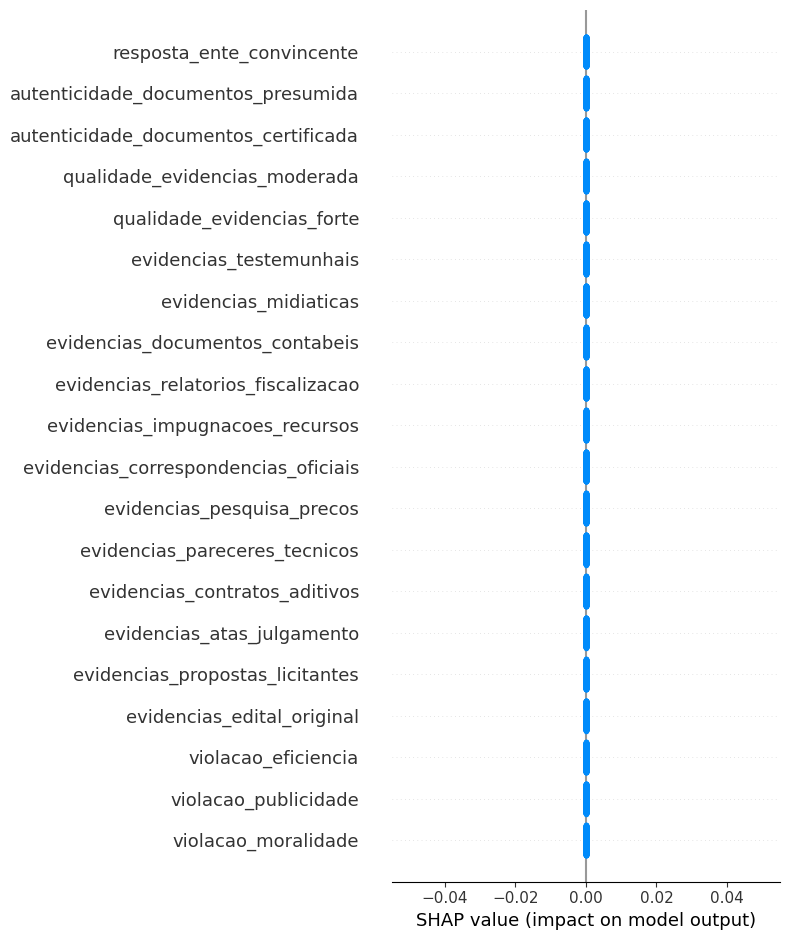

In [29]:
num_features = ["materialidade_valor"]
cat_features = list(cat_encoder.get_feature_names_out(lista_X))
feature_names = num_features + cat_features


explainer = shap.Explainer(best_model, X_importance)
shap_arr = explainer(X_importance).values
if shap_arr.ndim == 3:
    class_idx = 1 if shap_arr.shape[0] > 1 else 0
    shap_values = shap_arr[class_idx]  
else:
    shap_values = shap_arr


feature_to_original = [name.split("_")[0] for name in feature_names]
original_features = lista_X


shap_grouped = np.zeros((shap_values.shape[0], len(original_features)))
for i, orig in enumerate(original_features):
    idxs = [j for j, feat in enumerate(feature_to_original) if feat == orig]
    if len(idxs) > 0:
        shap_grouped[:, i] = np.abs(shap_values[:, idxs]).sum(axis=1)


shap.summary_plot(shap_grouped, feature_names=original_features)